# Logistic regression — scores, class overlap, and thresholds

The training helper `_tune_threshold_f1` in `src/clf_modeling.py` uses the **5th percentile** of **positive** `predict_proba` scores on **train**, then **clips** the threshold to `[0.01, 0.12]`. If every **test** `P(purchase)` is **below** the threshold you use, the model **never** predicts a purchase, so **precision / recall / F1 for the positive class are 0** while **accuracy** stays high (majority `y=0`).

This notebook:

1. Holds out **20% of `train_events`** (stratified) and plots **F1 / precision / recall vs threshold** on that validation set.
2. Compares the **range** of validation scores to **test** scores (same model) — a **calibration / covariate shift** issue: scores on a new time split can sit in a much **lower** band, so a threshold that works on validation in `[0.5, 1]` can be **infeasible** on test (nothing crosses it).
3. Picks a **low-band** validation threshold: **maximise F1** over `t ∈ [0, t_hi]` with `t_hi` a small value (e.g. **0.04**, near the test max in our runs) — **without** peeking at test — and evaluates on **`test_events`** for the **same 80% train / 20% val** fit.
4. (Optional) Plots the **test** F1–vs–threshold curve only as an **oracle** (you must **not** pick production thresholds from the test set).

**Prerequisite:** `data/train_events.csv` and `data/test_events.csv` (e.g. run `python src/baseline_model.py` once).

In [9]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split


def find_assignment2_root() -> Path:
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "src" / "data_prep.py").exists():
            return cand
    raise FileNotFoundError(
        "Could not find assignment2 root. Open this notebook from assignment2/ or notebooks/."
    )


ROOT = find_assignment2_root()
sys.path.insert(0, str(ROOT / "src"))

from clf_modeling import fit_clf, get_xy, predict_metrics  # noqa: E402

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["figure.dpi"] = 100

print("Repo root:", ROOT)

Repo root: /root/assignment2


In [10]:
train_path = ROOT / "data" / "train_events.csv"
test_path = ROOT / "data" / "test_events.csv"
if not train_path.is_file() or not test_path.is_file():
    raise FileNotFoundError(
        f"Missing {train_path} or {test_path}. Run baseline_model.py to build event tables."
    )

tr_ev = pd.read_csv(train_path)
te_ev = pd.read_csv(test_path)
print(f"train_events: {len(tr_ev):,} rows, y=1: {(tr_ev['y']==1).sum():,}")
print(f"test_events:  {len(te_ev):,} rows, y=1: {(te_ev['y']==1).sum():,}")

train_events: 134,773 rows, y=1: 42,353
test_events:  98,005 rows, y=1: 18,045


## 1. Stratified holdout from `train_events` + 80% fit (same stack as the baseline)

We use one random split (seed **42**). The fitted pipeline is the same as `fit_clf("log_reg", …)` in `clf_modeling.py`.

In [11]:
RANDOM_STATE = 42
VAL_FRAC = 0.2

tr_fit, tr_val = train_test_split(
    tr_ev,
    test_size=VAL_FRAC,
    random_state=RANDOM_STATE,
    stratify=tr_ev["y"],
)
pipe_sub, t_code_sub, _ = fit_clf("log_reg", tr_fit)
X_val, y_val = get_xy(tr_val.copy())
X_test, y_test = get_xy(te_ev.copy())
p_val = pipe_sub.predict_proba(X_val)[:, 1]
p_test_sub = pipe_sub.predict_proba(X_test)[:, 1]

print(
    "Validation scores: min, max, median:",
    f"{p_val.min():.4f}, {p_val.max():.4f}, {np.median(p_val):.4f}",
)
print(
    "Test scores (80% model):        min, max, median:",
    f"{p_test_sub.min():.4f}, {p_test_sub.max():.4f}, {np.median(p_test_sub):.4f}",
)
print(
    "\nA threshold chosen from **high** validation scores (e.g. argmax F1 on [0,1]) "
    "can be **> test max**; then (p_test >= t) is **all False** and F1 for class 1 is 0."
)

Validation scores: min, max, median: 0.0123, 1.0000, 0.2471
Test scores (80% model):        min, max, median: 0.0000, 0.0414, 0.0000

A threshold chosen from **high** validation scores (e.g. argmax F1 on [0,1]) can be **> test max**; then (p_test >= t) is **all False** and F1 for class 1 is 0.


In [12]:
thresholds_full = np.linspace(0.0, 1.0, 1001)
f1s_full = np.array(
    [f1_score(y_val, (p_val >= t).astype(int), zero_division=0) for t in thresholds_full]
)
precs_full = np.array(
    [precision_score(y_val, (p_val >= t).astype(int), zero_division=0) for t in thresholds_full]
)
recs_full = np.array(
    [recall_score(y_val, (p_val >= t).astype(int), zero_division=0) for t in thresholds_full]
)
idx_unconstrained = int(f1s_full.argmax())
t_f1_unconstrained = float(thresholds_full[idx_unconstrained])
print(f"(Validation) Unconstrained argmax F1: {f1s_full.max():.4f} at t = {t_f1_unconstrained:.4f}")

(Validation) Unconstrained argmax F1: 0.7999 at t = 0.5710


## 2. Low band only (no test labels): `t` in `[0, t_hi]`

If we only search **t ≤ 0.04** (upper bound is a *hypothesis* that deployment scores are small; adjust if your validation scores require it), we get a **different** `t*`. **Still check** on test: if `t*` > `p_test_sub.max()` you will get **no** positive predictions for that model on test.

In [13]:
T_HI = 0.04  # search cap (validation-only heuristic; not using test to set T_HI)
thresholds_low = np.linspace(0.0, T_HI, 501)
f1s_low = np.array(
    [f1_score(y_val, (p_val >= t).astype(int), zero_division=0) for t in thresholds_low]
)
idx_low = int(f1s_low.argmax())
t_f1_low_band = float(thresholds_low[idx_low])
print(f"(Validation) Max F1 on [0, {T_HI}] (grid): {f1s_low.max():.4f} at t = {t_f1_low_band:.4f}")

m_low_80 = predict_metrics(pipe_sub, te_ev, threshold=t_f1_low_band)
m_code_80 = predict_metrics(pipe_sub, te_ev, threshold=t_code_sub)
print(
    f"80% model + t_code (from fit_clf) — test F1: {m_code_80['f1']:.4f}  n_predicted+="
    f"{int(m_code_80['y_pred'].sum())}"
)
print(
    f"80% model + t low-band      — test F1: {m_low_80['f1']:.4f}  n_predicted+="
    f"{int(m_low_80['y_pred'].sum())}  (p_test max={p_test_sub.max():.4f})"
)

(Validation) Max F1 on [0, 0.04] (grid): 0.5372 at t = 0.0400
80% model + t_code (from fit_clf) — test F1: 0.0000  n_predicted+=0
80% model + t low-band      — test F1: 0.0002  n_predicted+=2  (p_test max=0.0414)


## 3. Full-train model (what `baseline_model.py` / MLflow do)

Same as production: `fit_clf` on all `train_events`.

In [14]:
pipe, t_code_full, _ = fit_clf("log_reg", tr_ev)
p_test_full = pipe.predict_proba(X_test)[:, 1]
m_def = predict_metrics(pipe, te_ev, threshold=t_code_full)
print(f"t_code (full-train) = {t_code_full:.6f}")
print(f"p_test (full) min/max = {p_test_full.min():.6f} / {p_test_full.max():.6f}")
print(f"Test metrics (default t):  F1={m_def['f1']:.4f}  n_pred+={int(m_def['y_pred'].sum())}")

t_code (full-train) = 0.120000
p_test (full) min/max = 0.000000 / 0.035077
Test metrics (default t):  F1=0.0000  n_pred+=0


## 4. Plots

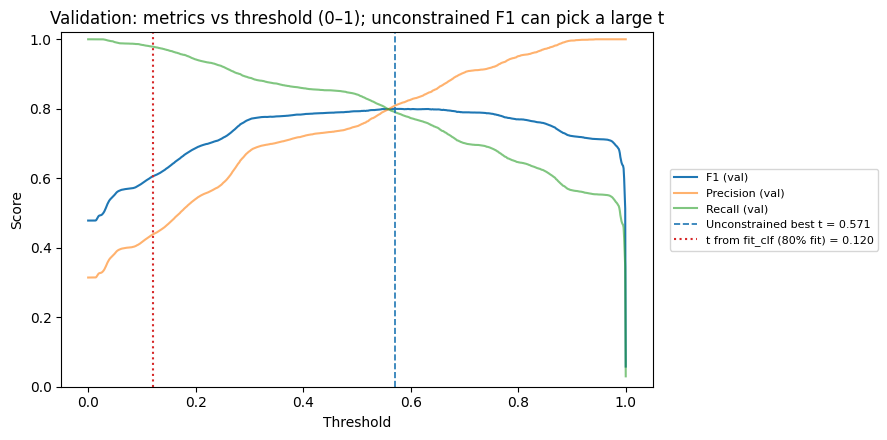

In [15]:
fig, ax = plt.subplots()
ax.plot(thresholds_full, f1s_full, label="F1 (val)", color="C0")
ax.plot(thresholds_full, precs_full, alpha=0.6, label="Precision (val)", color="C1")
ax.plot(thresholds_full, recs_full, alpha=0.6, label="Recall (val)", color="C2")
ax.axvline(t_f1_unconstrained, color="C0", linestyle="--", lw=1.2, label=f"Unconstrained best t = {t_f1_unconstrained:.3f}")
ax.axvline(t_code_sub, color="C3", linestyle=":", label=f"t from fit_clf (80% fit) = {t_code_sub:.3f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Validation: metrics vs threshold (0–1); unconstrained F1 can pick a large t")
ax.set_ylim(0, 1.02)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

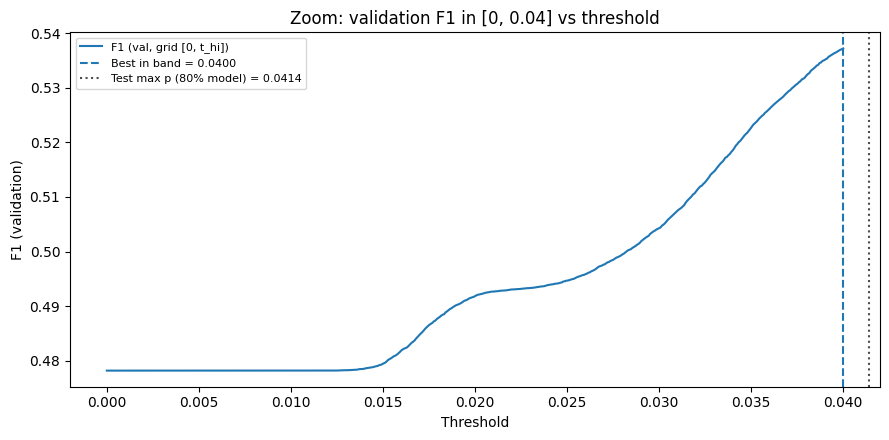

In [16]:
fig, ax = plt.subplots()
ax.plot(thresholds_low, f1s_low, color="C0", label="F1 (val, grid [0, t_hi])")
ax.axvline(t_f1_low_band, color="C0", ls="--", label=f"Best in band = {t_f1_low_band:.4f}")
ax.axvline(p_test_sub.max(), color="0.3", ls=":", label=f"Test max p (80% model) = {p_test_sub.max():.4f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("F1 (validation)")
ax.set_title(f"Zoom: validation F1 in [0, {T_HI}] vs threshold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

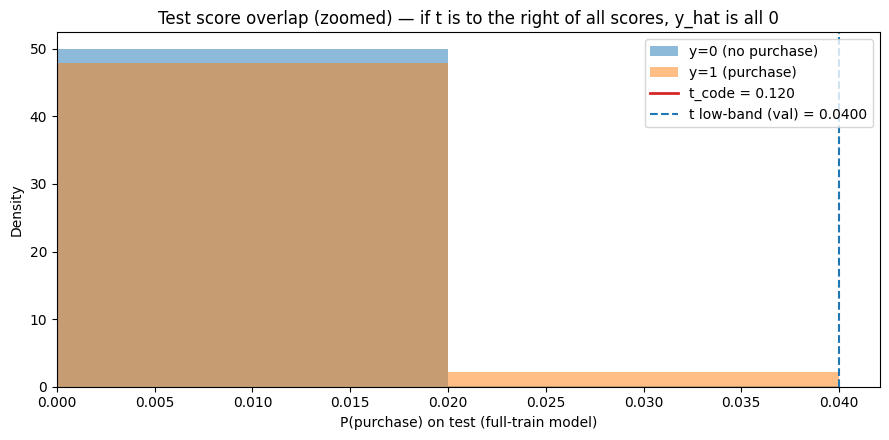

Share with P >= t_code: 0.0000%
Share with P >= t low-band: 0.0000%


In [17]:
fig, ax = plt.subplots()
ax.hist(
    p_test_full[y_test == 0],
    bins=50,
    range=(0, 1),
    alpha=0.5,
    label="y=0 (no purchase)",
    density=True,
)
ax.hist(
    p_test_full[y_test == 1],
    bins=50,
    range=(0, 1),
    alpha=0.5,
    label="y=1 (purchase)",
    density=True,
)
ax.set_xlim(0, min(0.2, p_test_full.max() * 1.2 + 1e-6))
ax.axvline(t_code_full, color="C3", lw=2, label=f"t_code = {t_code_full:.3f}")
ax.axvline(t_f1_low_band, color="C0", ls="--", lw=1.5, label=f"t low-band (val) = {t_f1_low_band:.4f}")
ax.set_xlabel("P(purchase) on test (full-train model)")
ax.set_ylabel("Density")
ax.set_title("Test score overlap (zoomed) — if t is to the right of all scores, y_hat is all 0")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Share with P >= t_code: {float((p_test_full >= t_code_full).mean()):.4%}")
print(f"Share with P >= t low-band: {float((p_test_full >= t_f1_low_band).mean()):.4%}")

## 5. Oracle: F1 on **test** vs `t` (illustration only — **do not** choose a production threshold from this)

Shows where the best **test** F1 lies; it is *not* an unbiased estimate. Use a clean validation or calibration split for real work.

(Oracle) Best test F1 in [0, 0.2]: 0.7281 at t = 0.0007
Default t vs oracle: 0.12 0.0007


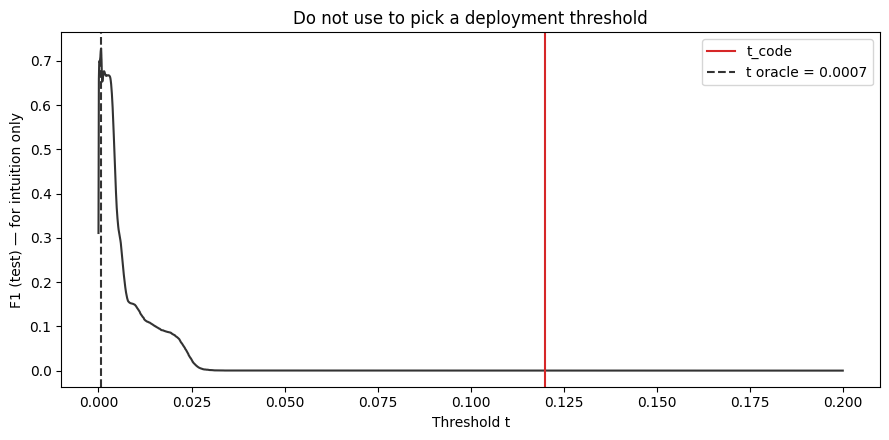

In [18]:
t_fine = np.linspace(0.0, 0.2, 2001)
f1_test = np.array(
    [f1_score(y_test, (p_test_full >= t).astype(int), zero_division=0) for t in t_fine]
)
j = int(f1_test.argmax())
t_oracle = float(t_fine[j])
print(f"(Oracle) Best test F1 in [0, 0.2]: {f1_test[j]:.4f} at t = {t_oracle:.4f}")
print("Default t vs oracle:", t_code_full, t_oracle)

fig, ax = plt.subplots()
ax.plot(t_fine, f1_test, color="0.2")
ax.axvline(t_code_full, color="C3", label="t_code")
ax.axvline(t_oracle, color="0.2", ls="--", label=f"t oracle = {t_oracle:.4f}")
ax.set_xlabel("Threshold t")
ax.set_ylabel("F1 (test) — for intuition only")
ax.set_title("Do not use to pick a deployment threshold")
ax.legend()
plt.tight_layout()
plt.show()